In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from pycaret.regression import *

from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Data Prep


In [2]:
data_23_24 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fantasyGo_FPL.csv')
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')

In [3]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'score', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'score_bps_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'score_bps_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'score_bps_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'score_bps_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'score_bps_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]


cols = [ 'creativity','ict_index', 'influence','selected',  'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home',
        'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'round', 'fpl_name', 'xP', 'team', 'opponent_team', 'position',


        'opponent_xgc_3', 'opponent_xgc_5', 'opponent_gc_3', 'opponent_gc_5', 'opponent_goals_scored_3', 'opponent_goals_scored_5', 'team_was_home', 'opponent_ict', 'opponent_xG',
        'opponent_xA', 'opponent_goals_scored', 'opponent_shots', 'opponent_npxG', 'opponent_value', 'opponent_whh', 'opponent_whd', 'opponent_wha', 'opponent_difficulty',

        'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
        'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
        'team_a_score_1', 'team_h_score_1', 'score_bps_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1',  'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',
        'xP_1',

        'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
        'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
        'team_a_score_3', 'team_h_score_3', 'score_bps_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3',  'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',
        'xP_3',

        'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
        'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
        'team_a_score_5', 'team_h_score_5', 'score_bps_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5',  'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',
        'xP_5',

        ]


## 23/24 - Data Prep


In [4]:
play_data = data_23_24.copy()


play_data['gw'] = play_data['round']
play_data['team'] = play_data['player_team']
play_data['opponent_team'] = play_data.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)
play_data[['h_team', 'a_team', 'was_home', 'team', 'opponent_team', 'player_team', 'gw', 'round']]


sum_features = [
    'creativity', 'influence', 'threat',
    'expected_goals_1', 'expected_assists_1', 'expected_goal_involvements_1',
    'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1',
    'shots_1', 'key_passes_1', 'npg_1', 'npxG_1',
]

mean_features = [
    'value', 'ict_index', 'selected', 'transfers_in', 'transfers_out'
]

# max_features = [
#     'minutes_1', 'influence'
# ]

identity_features = [
    'whh', 'whd', 'wha',    # bookmaker odds
    'was_home',
    'opponent_team'
]

team_df = play_data.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()

for col in ['expected_goals_conceded_1','goals_conceded_1','goals_scored_1']:
    team_df[f'{col}_3'] = team_df.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df[f'{col}_5'] = team_df.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)

team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })

opponent_stats = team_df[['team', 'gw','team_ict_index', 'team_expected_goals', 'team_expected_assists', 'team_goals_scored', 'team_shots', 'team_npxG', 'team_value',
                          'team_whh', 'team_whd', 'team_wha', 'team_expected_goals_conceded_3', 'team_expected_goals_conceded_5', 'team_goals_conceded_3', 'team_goals_conceded_5',
                          'team_goals_scored_3', 'team_goals_scored_5']].rename(

                columns={'team': 'opponent_team', 'team_ict_index':'opponent_ict','team_expected_goals': 'opponent_xG', 'team_expected_assists': 'opponent_xA',
                        'team_goals_scored': 'opponent_goals_scored', 'team_shots': 'opponent_shots', 'team_npxG': 'opponent_npxG', 'team_value': 'opponent_value',
                        'team_whh': 'opponent_whh', 'team_whd': 'opponent_whd', 'team_wha': 'opponent_wha', 'team_expected_goals_conceded_3': 'opponent_xgc_3',
                        'team_expected_goals_conceded_5': 'opponent_xgc_5', 'team_goals_conceded_3': 'opponent_gc_3', 'team_goals_conceded_5': 'opponent_gc_5',
                        'team_goals_scored_3': 'opponent_goals_scored_3', 'team_goals_scored_5': 'opponent_goals_scored_5'
                        })

# 2. Merge this back into the original dataframe matching on 'opponent_team' and 'gw'
team_df = team_df.merge(opponent_stats, on=['opponent_team', 'gw'], how='left')

final_df = play_data.merge(team_df, on=['opponent_team', 'team','gw'], how='left')

# ODI = Probability of Draw + Probability of Away Win (assuming player's team is Home odds)
# A high ODI means a tough fixture (Player's team is less likely to win).
# ODI = Probability of Draw + Probability of Home Win (assuming player's team is Away odds)
# A high ODI means a tough fixture (Player's team is more likely to win).
final_df['opponent_difficulty'] = final_df.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['h_team']
    else (row['whd'] + row['whh']),
    axis=1
)

final_df['team_difficulty'] = final_df.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['a_team']
    else (row['whd'] + row['whh']),
    axis=1
)


CATEGORICAL_COLS = ['position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(final_df[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(final_df[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=final_df.index
)


cols = [*cols, *encoded_cols]
# Combine with numerical data
final_df = pd.concat([final_df, encoded_df], axis=1) #.drop(columns=CATEGORICAL_COLS)
final_df

,Unnamed: 0,fpl_id,round,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,...,opponent_team_Liverpool,opponent_team_Luton,opponent_team_Manchester City,opponent_team_Manchester United,opponent_team_Newcastle United,opponent_team_Nottingham Forest,opponent_team_Sheffield United,opponent_team_Tottenham Hotspur,opponent_team_West Ham United,opponent_team_Wolverhampton Wanderers
0,0,145,1,0.0,0.0,9.0,0.0,0.0,145.0,0.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,151,1,0.0,0.0,2.0,0.0,0.3,151.0,0.00,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,401,1,1.0,3.0,40.0,1.0,37.4,401.0,0.78,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,131,1,1.0,3.0,34.0,0.0,79.3,131.0,0.86,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,143,1,1.0,1.0,26.0,0.0,61.9,143.0,0.62,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4921,4921,421,38,0.0,0.0,12.0,0.0,2.3,421.0,0.06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4922,4922,544,38,0.0,0.0,14.0,0.0,0.2,544.0,0.00,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4923,4923,545,38,0.0,0.0,11.0,0.0,12.4,545.0,0.08,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4924,4924,70,38,0.0,0.0,3.0,0.0,0.2,70.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
final_df['team'].unique(), len(final_df['team'].unique())

(array(['Chelsea', 'Brighton and Hove Albion', 'Manchester United',
        'West Ham United', 'Crystal Palace', 'Manchester City', 'Arsenal',
        'Newcastle United', 'Sheffield United', 'Luton', 'Fulham',
        'Aston Villa', 'Everton', 'Brentford', 'Liverpool',
        'Tottenham Hotspur', 'Bournemouth', 'Burnley', 'Nottingham Forest',
        'Wolverhampton Wanderers', 'Mainz 05'], dtype=object),
 21)

In [6]:

final_df[final_df['team'] == 'Mainz 05'][['fpl_name','round',  'FPL_Name', 'date', 'a_team', 'h_team']]

,fpl_name,round,FPL_Name,date,a_team,h_team
3370,David Datro Fofana,26,David Datro Fofana,2024-02-24,Burnley,Crystal Palace
3490,David Datro Fofana,27,David Datro Fofana,2024-03-03,Bournemouth,Burnley
3665,David Datro Fofana,29,David Datro Fofana,2024-03-16,Brentford,Burnley
3934,David Datro Fofana,31,David Datro Fofana,2024-04-02,Wolverhampton Wanderers,Burnley
4225,David Datro Fofana,33,David Datro Fofana,2024-04-13,Brighton and Hove Albion,Burnley
4287,David Datro Fofana,34,David Datro Fofana,2024-04-20,Burnley,Sheffield United
4631,David Datro Fofana,36,David Datro Fofana,2024-05-04,Newcastle United,Burnley


In [7]:
# Cole Palmer is still in mancity not chelsea
# Fofana moved to chealse mid season
final_df.loc[final_df['FPL_Name'] == 'Cole Palmer', 'team'] = 'Chelsea'
final_df.loc[final_df['team'] == 'Mainz 05', 'team'] = 'Chelsea'
final_df['team'].unique(), len(final_df['team'].unique())

(array(['Chelsea', 'Brighton and Hove Albion', 'Manchester United',
        'West Ham United', 'Crystal Palace', 'Manchester City', 'Arsenal',
        'Newcastle United', 'Sheffield United', 'Luton', 'Fulham',
        'Aston Villa', 'Everton', 'Brentford', 'Liverpool',
        'Tottenham Hotspur', 'Bournemouth', 'Burnley', 'Nottingham Forest',
        'Wolverhampton Wanderers'], dtype=object),
 20)

In [ ]:
def working_df(data, gw):
    GW_full = data['round'].values

    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data[train_mask]
    test_data = data[test_mask]


    test_player_names = test_data['fpl_name'].values
    test_data = test_data[cols].drop(columns=['fpl_name', 'team', 'opponent_team', 'position'])
    train_data = train_data[cols].drop(columns=['fpl_name', 'team', 'opponent_team', 'position'])

    return train_data, test_data, test_player_names



### GW 31


#### Train


In [38]:
train_data, test_data, player_names = working_df(final_df, 31)

In [12]:
base_model = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features

                )

best_model = base_model.compare_models(sort='MAE', n_select=1)
best_model

,Description,Value
0,Session id,5999
1,Target,xP
2,Target type,Regression
3,Original data shape,"(3844, 181)"
4,Transformed data shape,"(3844, 151)"
5,Transformed train set shape,"(3075, 151)"
6,Transformed test set shape,"(769, 151)"
7,Numeric features,178
8,Categorical features,1
9,Rows with missing values,10.5%


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8276,1.2994,1.1373,0.7351,0.2963,0.3966,51.9170
gbr,Gradient Boosting Regressor,0.8816,1.4205,1.1894,0.7108,0.3117,0.4361,2.0180
et,Extra Trees Regressor,0.9096,1.6814,1.2925,0.6597,0.3452,0.4392,5.2400
rf,Random Forest Regressor,0.9171,1.6600,1.2849,0.6636,0.3434,0.4463,7.6530
ridge,Ridge Regression,0.9901,1.8950,1.3731,0.6146,0.3693,0.4478,0.4620
lr,Linear Regression,0.9906,1.9031,1.3758,0.6136,0.3701,0.4492,0.4960
omp,Orthogonal Matching Pursuit,1.0947,2.3299,1.5238,0.5256,0.4059,0.5539,0.2290
ada,AdaBoost Regressor,1.1100,2.0621,1.4344,0.5810,0.4032,0.6602,1.3650
en,Elastic Net,1.1272,2.3171,1.5203,0.5287,0.4062,0.5916,0.6490
llar,Lasso Least Angle Regression,1.2198,2.6297,1.6205,0.4639,0.4293,0.6617,0.3040


LGBMRegressor(n_jobs=-1, random_state=5999)

In [15]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

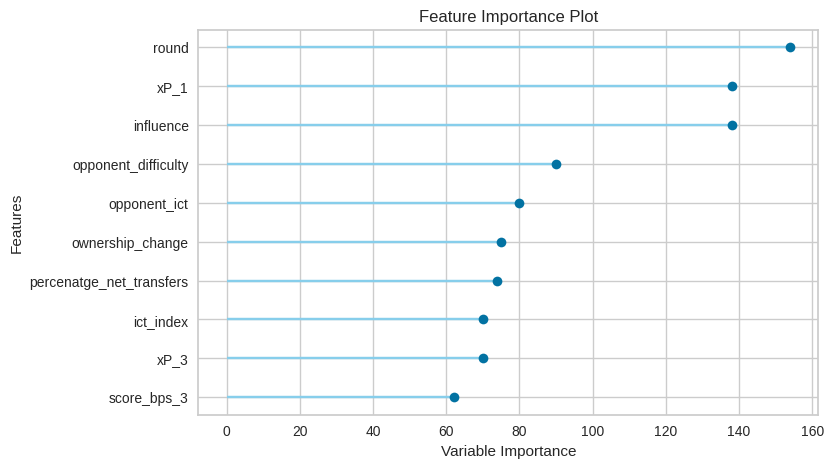

In [16]:
plot_model(best_model, plot='feature')        # Feature importance

##### Tune Model


In [ ]:
# tuned = tune_model(base_def_xg_best,
#                 #    verbose = False,   # This keeps the PyCaret grid visible
#                    return_train_score = True,
#                    optimize='MAE')

#### Predict


In [39]:
test_df = test_data.copy()
test_target = test_data['xP']
test_data_features = test_data.drop(columns=['xP'])

In [40]:
prediction = predict_model(best_model, test_data_features)
prediction

,creativity,ict_index,influence,selected,threat,transfers_balance,transfers_in,transfers_out,value,was_home,...,opponent_team_Luton,opponent_team_Manchester City,opponent_team_Manchester United,opponent_team_Newcastle United,opponent_team_Nottingham Forest,opponent_team_Sheffield United,opponent_team_Tottenham Hotspur,opponent_team_West Ham United,opponent_team_Wolverhampton Wanderers,prediction_label
3844,0.000000,1.200000,12.400000,852100.0,0.0,128216.0,138224.0,10008.0,5.0,True,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.848017
3845,5.500000,4.900000,26.400000,1164639.0,17.0,5294.0,36233.0,30939.0,5.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.534963
3846,16.200001,4.700000,30.600000,481541.0,0.0,61015.0,65273.0,4258.0,4.9,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.453896
3847,19.100000,5.200000,7.800000,3879175.0,25.0,544816.0,548441.0,3625.0,13.3,True,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,6.574063
3848,45.299999,20.299999,115.800003,3405836.0,42.0,-70053.0,85642.0,155695.0,8.1,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.907196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3963,11.100000,2.600000,5.800000,664510.0,9.0,1168.0,10278.0,9110.0,6.3,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.451954
3964,10.300000,1.600000,3.600000,10037.0,2.0,3620.0,4323.0,703.0,5.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.539222
3965,4.500000,2.700000,11.800000,219080.0,11.0,-32836.0,3024.0,35860.0,4.9,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.212160
3966,0.600000,1.600000,2.200000,356260.0,13.0,-2276.0,896.0,3172.0,5.1,True,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.318745


In [41]:
xP_pred = prediction['prediction_label']

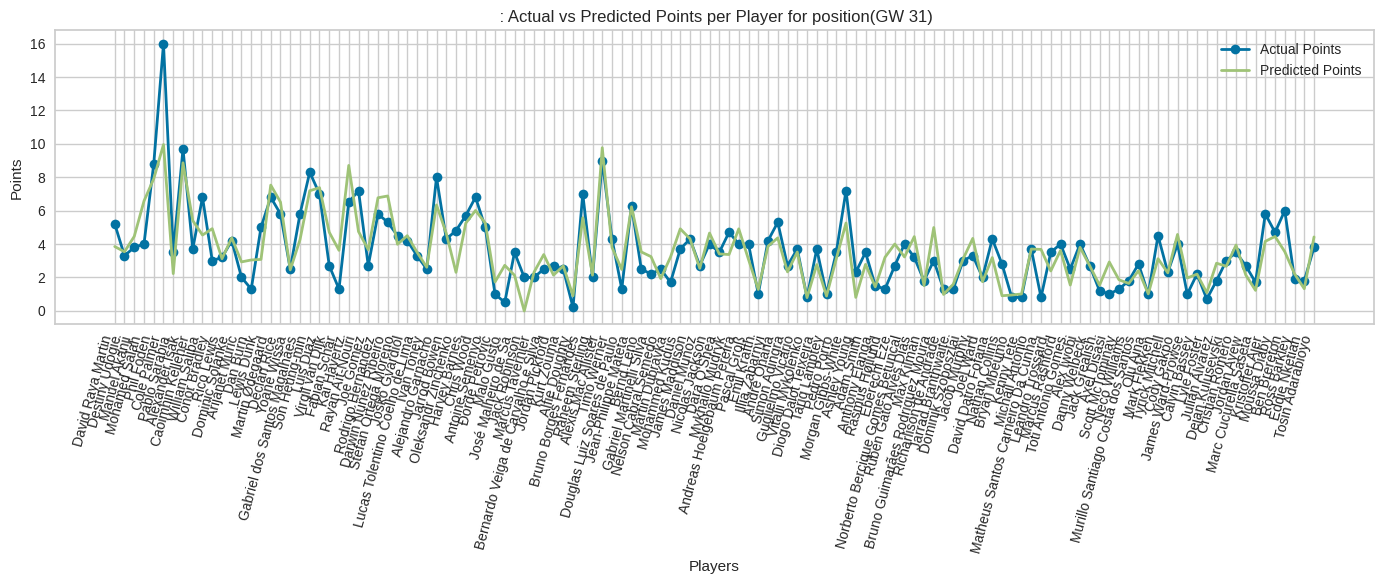

In [46]:
xp_actual = test_target
xp_pred = xP_pred.values


# Convert names to positions on x-axis
x = np.arange(len(player_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, player_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title(f" : Actual vs Predicted Points per Player for position(GW 31)")
plt.legend()
plt.tight_layout()

plt.show()

